### Import required libraries

In [1]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from sklearn.model_selection import train_test_split

### Data collection

In [2]:
# Import dataset
original_df = pd.read_csv("/Users/aniket/Desktop/Projects/Project Resources/\
WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("\nOriginal DataFrame: \n", original_df.head())

# Check for missing values and get count of Non-nulls.
print("\nTotal nulls in each feature: \n", original_df.isnull().sum())
# No need to take count of non-nulls as there are no nulls in this dataset.

# Target variables for survival analysis are already identified and present
# in the dataset:
# duration = tenure; event = churn
# Make feature names cases consistent
original_df.columns = original_df.columns.str.lower()

# Convert to float, replacing any non-numeric values with NaN
original_df['totalcharges'] = pd.to_numeric(original_df['totalcharges'],
                                   errors='coerce')

# Change the data types wherever required
original_df["totalcharges"] = original_df["totalcharges"].astype(float)

# Check new data types of all the features.
print("\nNew data types: \n", original_df.dtypes)


Original DataFrame: 
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovi

### Exploratory Data Analysis


Unique values in "churn" column: 
 churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rates (%): 
 churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


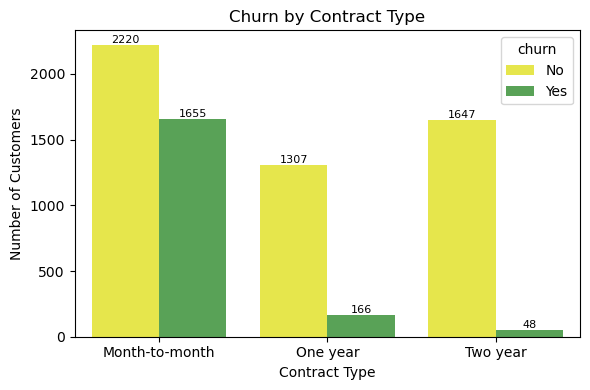

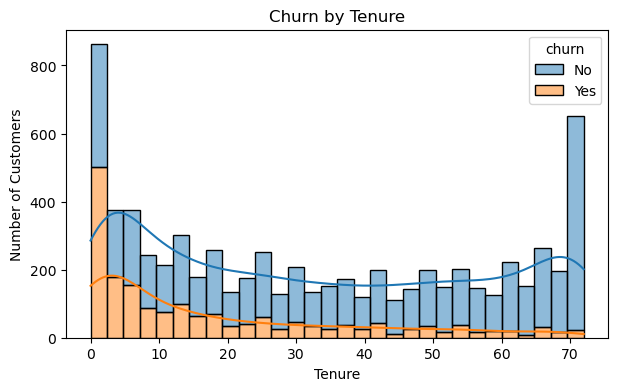

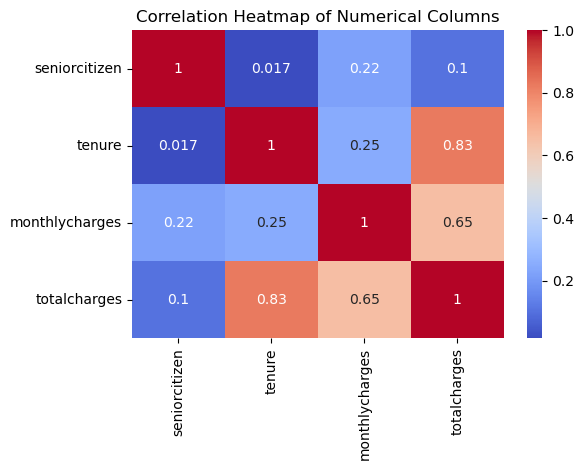

In [3]:
# Check the churn rate
print('\nUnique values in "churn" column: \n',\
      original_df["churn"].value_counts())
churn_rate = original_df["churn"].value_counts(normalize=True) * 100
print("\nChurn Rates (%): \n", churn_rate.round(2))

## Churn Proportions
# 1. Churn proportion by contract type
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=original_df, x="contract", hue="churn",\
                   palette="Set1_r")
# Loop through all bar containers and add labels to each one
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

# 2. Churn proportion by tenure
plt.figure(figsize=(7, 4))
sns.histplot(data=original_df, x="tenure", hue="churn", bins=30,
             kde=True, multiple="stack")
plt.title("Churn by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.show()

# Correlation between numerical variables
num_cols = ["seniorcitizen", "tenure", "monthlycharges", "totalcharges"]

# Correlation heatmap of numerical columns
plt.figure(figsize=(6, 4))
sns.heatmap(original_df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Columns")
plt.show()

### Feature engineering


Modified DataFrame: 
    gender  seniorcitizen partner dependents phoneservice     multiplelines  \
0  Female              0     Yes         No           No  No phone service   
1    Male              0      No         No          Yes                No   
2    Male              0      No         No          Yes                No   
3    Male              0      No         No           No  No phone service   
4  Female              0      No         No          Yes                No   

  internetservice onlinesecurity onlinebackup deviceprotection techsupport  \
0             DSL             No          Yes               No          No   
1             DSL            Yes           No              Yes          No   
2             DSL            Yes          Yes               No          No   
3             DSL            Yes           No              Yes         Yes   
4     Fiber optic             No           No               No          No   

  streamingtv streamingmovies        co

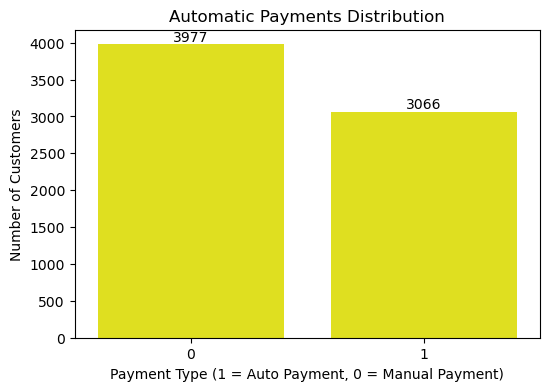


Encoded DataFrame: 
    seniorcitizen  monthlycharges  totalcharges  duration  event  autopayment  \
0              0           29.85         29.85         1      0            0   
1              0           56.95       1889.50        34      0            0   
2              0           53.85        108.15         2      1            0   
3              0           42.30       1840.75        45      0            1   
4              0           70.70        151.65         2      1            0   

   gender_Male  partner_Yes  dependents_Yes  phoneservice_Yes  ...  \
0        False         True           False             False  ...   
1         True        False           False              True  ...   
2         True        False           False              True  ...   
3         True        False           False             False  ...   
4        False        False           False              True  ...   

   streamingtv_No internet service  streamingtv_Yes  \
0                    

In [4]:
# Add time-to-event and event columns
original_df["duration"] = original_df["tenure"]
original_df["event"] = original_df["churn"].map({"Yes": 1, "No": 0})
# 1 = Churned, 0 = Active

# Drop irrelevant features
modified_df = original_df.drop(["customerid", "churn", "tenure"], axis=1)
print("\nModified DataFrame: \n", modified_df.head())

# Create new engineered features
# 1. Feature for automatic payment vs manual
modified_df["autopayment"] = modified_df["paymentmethod"]\
    .apply(lambda x: 1 if "automatic" in x.lower() else 0)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=modified_df, x="autopayment", color="yellow")
ax.bar_label(ax.containers[0], fontsize=10)
ax.set_title("Automatic Payments Distribution")
ax.set_xlabel("Payment Type (1 = Auto Payment, 0 = Manual Payment)")
ax.set_ylabel("Number of Customers")
plt.show()

# Encode the categorical columns
cat_cols = modified_df.select_dtypes(include=["object"]).columns.to_list()

encoded_df = pd.get_dummies(data=modified_df, columns=cat_cols,
                            drop_first=False)
print("\nEncoded DataFrame: \n", encoded_df.head())

### Preprocessing for survival models

In [5]:
# Split the data
df_train, df_test = train_test_split(
    encoded_df,
    train_size=0.8,
    random_state=25,
    stratify=encoded_df["event"]
    )

# Print the shapes to verify the split
print("\nShape of training set (df_train):", df_train.shape)
print("Shape of testing set (df_test):", df_test.shape)
print("\nChurn proportion in training set:\n",\
      df_train['event'].value_counts(normalize=True).round(2) * 100)
print("\nChurn proportion in testing set:\n",\
      df_test['event'].value_counts(normalize=True).round(2) * 100)

# Save both train and test datasets in csv format
df_train.to_parquet("/Users/aniket/Desktop/Projects/Project Resources/\
project 2 df_train.parquet", index=False)
df_test.to_parquet("/Users/aniket/Desktop/Projects/Project Resources/\
project 2 df_test.parquet", index=False)

print("\nTrain & Test datasets have been successfully saved.")



Shape of training set (df_train): (5634, 32)
Shape of testing set (df_test): (1409, 32)

Churn proportion in training set:
 event
0    73.0
1    27.0
Name: proportion, dtype: float64

Churn proportion in testing set:
 event
0    73.0
1    27.0
Name: proportion, dtype: float64

Train & Test datasets have been successfully saved.


### Survival analysis modeling


Median Survival Time: inf


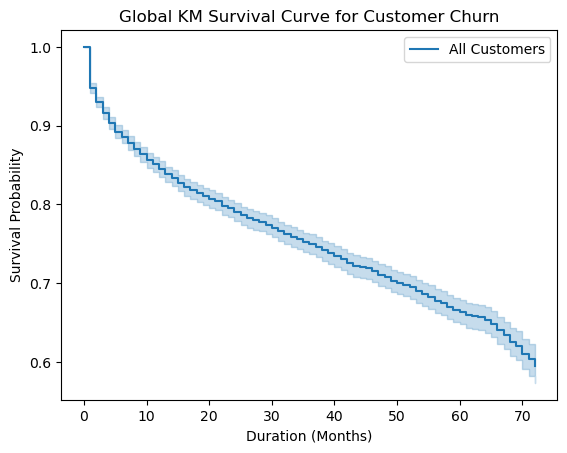


Survival Funtion At Times:
 10    0.856442
30    0.770578
50    0.700041
65    0.648653
68    0.625854
Name: All Customers, dtype: float64


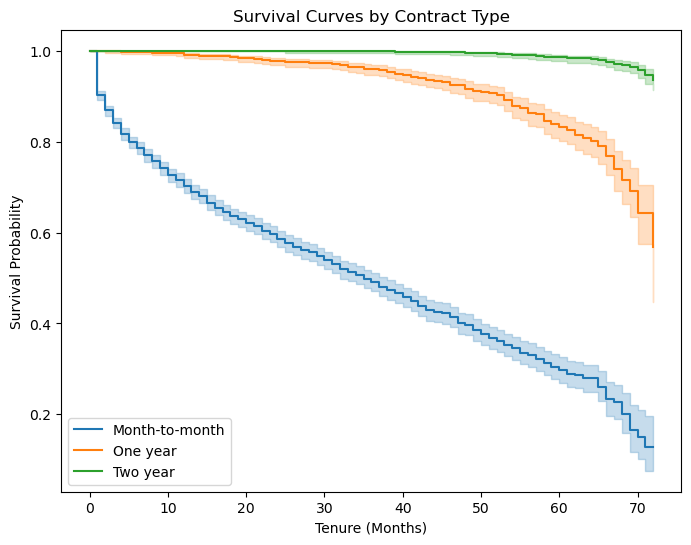

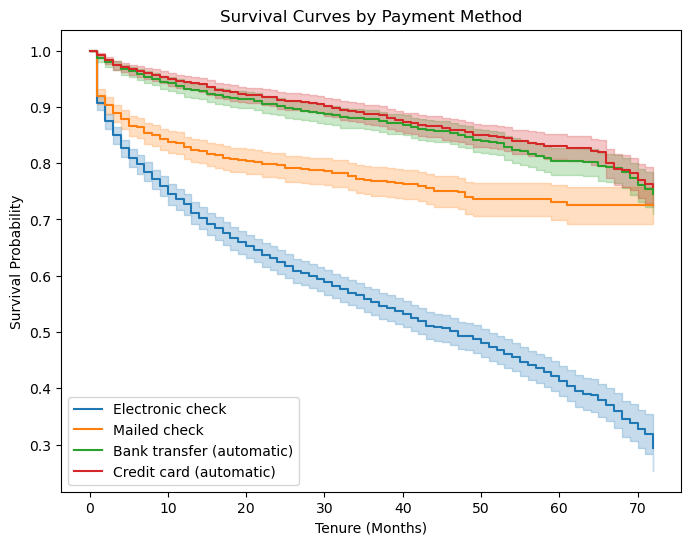

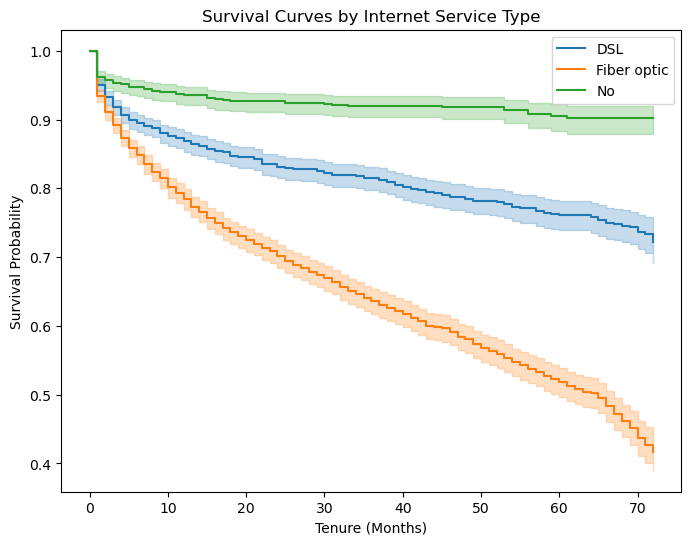


seniorcitizen                            0
monthlycharges                           0
totalcharges                             9
duration                                 0
event                                    0
autopayment                              0
gender_Male                              0
partner_Yes                              0
dependents_Yes                           0
phoneservice_Yes                         0
multiplelines_No phone service           0
multiplelines_Yes                        0
internetservice_Fiber optic              0
internetservice_No                       0
onlinesecurity_No internet service       0
onlinesecurity_Yes                       0
onlinebackup_No internet service         0
onlinebackup_Yes                         0
deviceprotection_No internet service     0
deviceprotection_Yes                     0
techsupport_No internet service          0
techsupport_Yes                          0
streamingtv_No internet service          0
streamingt

<lifelines.CoxPHFitter: fitted with 5625 total observations, 4130 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.0008
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 5625
number of events observed = 1495
   partial log-likelihood = -9779.26
         time fit was run = 2025-10-30 04:48:58 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
seniorcitizen                          0.05      1.05      0.06           -0.07            0.17                0.93                1.19
monthlycharges                         0.01      1.01      0.01           -0.01            0.03                0.99                1.04
totalcharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
autopayment                           -0.30      0.74      0.59           -1.45            0.86                0.23                2.36
gender_Male                           -0.07      0.93      0.05           -0.17            0.03                0.84                1.03
partner_Yes                           -0.21      0.81      0.06           -0.33           -0.09                0.72                0.92
dependents_Yes                        -0.05      0.95      0.08           -0.20            0.10                0.82                1.11
phoneservice_Yes                       0.38      1.47      1.13           -1.84            2.61                0.16               13.53
multiplelines_No phone service        -0.38      0.68      1.13           -2.61            1.84                0.07                6.30
multiplelines_Yes                      0.10      1.11      0.08           -0.06            0.27                0.94                1.31
internetservice_Fiber optic            1.10      3.00      0.31            0.48            1.71                1.62                5.53
internetservice_No                    -0.33      0.72      1.06           -2.41            1.75                0.09                5.75
onlinesecurity_No internet service    -0.33      0.72      1.06           -2.41            1.75                0.09                5.75
onlinesecurity_Yes                    -0.21      0.81      0.10           -0.40           -0.01                0.67                0.99
onlinebackup_No internet service      -0.33      0.72      1.06           -2.41            1.75                0.09                5.75
onlinebackup_Yes                      -0.02      0.98      0.09           -0.19            0.15                0.83                1.16
deviceprotection_No internet service  -0.33      0.72      1.06           -2.41            1.75                0.09                5.75
deviceprotection_Yes                   0.11      1.12      0.09           -0.05            0.28                0.95                1.32
techsupport_No internet service       -0.33      0.72      1.06           -2.41            1.75                0.09                5.75
techsupport_Yes                       -0.08      0.92      0.10           -0.27            0.11                0.77                1.11
streamingtv_No internet service       -0.33      0.72      1.06           -2.41            1.75                0.09                5.75
streamingtv_Yes                        0.31      1.36      0.13            0.04            0.57                1.04                1.77
streamingmovies_No internet service   -0.33      0.72      1.06           -2.41            1.75                0.09                5.75
streamingmovies_Yes                    0.28      1.32      0.13            0.01            0.54                1.01                1.71
contract_One year              

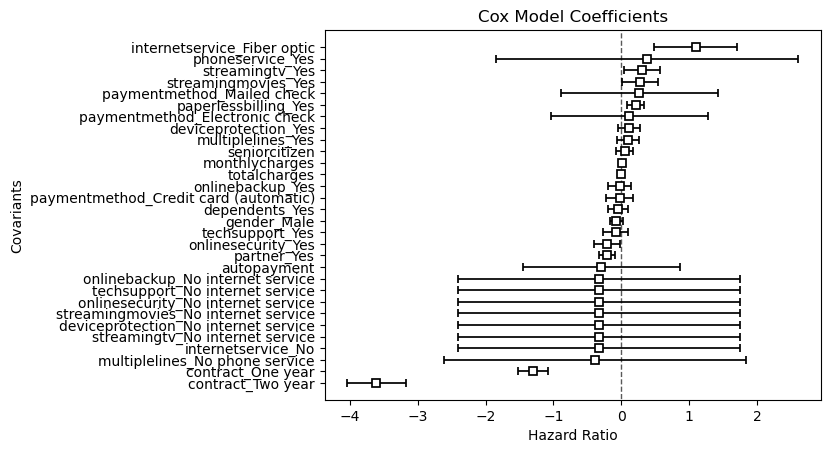

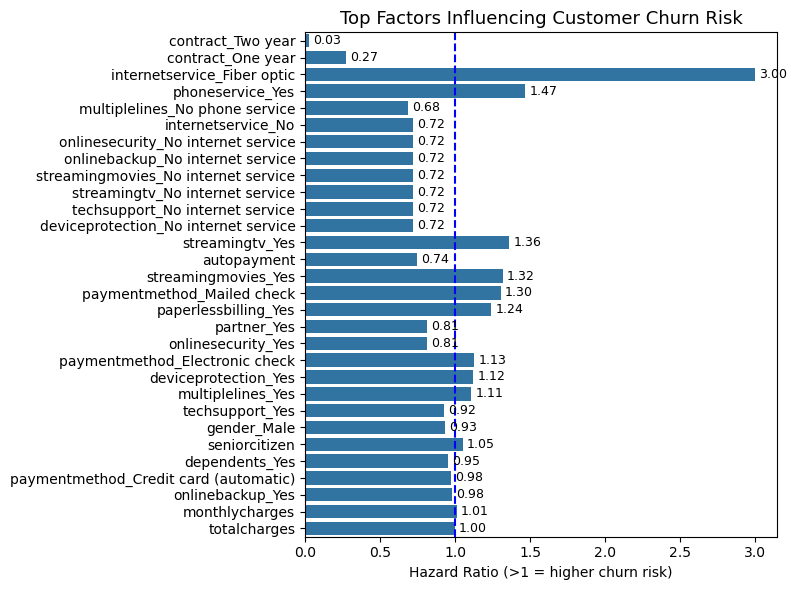

✅ Cox model saved as cph_model.pkl


In [6]:
## Fit Kaplan-Meier Estimator for global survival curve.
# Instantiate the KM Estimator
kmf = KaplanMeierFitter()

# Fit the KM Estimator to the entire data
kmf.fit(durations=df_train["duration"], event_observed=df_train["event"],
        label="All Customers")

# Get the median survival time
median_surv_time = kmf.median_survival_time_
print(f"\nMedian Survival Time: {median_surv_time:.2f}")

"""Since the survival probability never drops below 50% within your dataset,
the median survival time cannot be calculated from the available data. It is
therefore reported as infinite (inf)."""

# Plot the KM Survival Curve
kmf.plot_survival_function(ci_show=True)
plt.title("Global KM Survival Curve for Customer Churn")
plt.xlabel("Duration (Months)")
plt.ylabel("Survival Probability")
plt.show()

# Print survival function at given times
print("\nSurvival Funtion At Times:\n",\
       kmf.survival_function_at_times([10, 30, 50, 65, 68]))

## Compare survival by different features
# 1. Comapre survival by contract type
kmf_contract = KaplanMeierFitter()

plt.figure(figsize=(8, 6))
for contract_type in modified_df["contract"].unique():
    mask = modified_df["contract"] == contract_type
    kmf_contract.fit(durations=modified_df.loc[mask, "duration"],
                     event_observed=modified_df.loc[mask, "event"],
                     label=contract_type)
    kmf_contract.plot_survival_function()

plt.title("Survival Curves by Contract Type")
plt.xlabel("Tenure (Months)")
plt.ylabel("Survival Probability")
plt.show()

# 2. Compare survival function by payment method
kmf_paymentmethod = KaplanMeierFitter()

plt.figure(figsize=(8, 6))
for method in modified_df["paymentmethod"].unique():
    mask = modified_df["paymentmethod"] == method
    kmf_paymentmethod.fit(durations=modified_df.loc[mask, "duration"],
                          event_observed=modified_df.loc[mask, "event"],
                          label=method)
    kmf_paymentmethod.plot_survival_function()

plt.title("Survival Curves by Payment Method")
plt.xlabel("Tenure (Months)")
plt.ylabel("Survival Probability")
plt.show()

# 3. Compare survival function by internet service type
kmf_internettype = KaplanMeierFitter()

plt.figure(figsize=(8, 6))
for internet_type in modified_df["internetservice"].unique():
    mask = modified_df["internetservice"] == internet_type
    kmf_internettype.fit(durations=modified_df.loc[mask, "duration"],
                         event_observed=modified_df.loc[mask, "event"],
                         label=internet_type)
    kmf_internettype.plot_survival_function()

plt.title("Survival Curves by Internet Service Type")
plt.xlabel("Tenure (Months)")
plt.ylabel("Survival Probability")
plt.show()

## Fit Cox Proportional Hazards Model
# Identify and handle missing values
print()
print(df_train.isnull().sum())
df_train = df_train.dropna()

# Instantiate the model
cph = CoxPHFitter(penalizer=0.0008)

# Fit the Cox PH model to the train dataframe
cph.fit(df_train, duration_col="duration", event_col="event")

# Print the model summary
cph.print_summary()

# Plot the model coefficients
cph.plot()
plt.title("Cox Model Coefficients")
plt.xlabel("Hazard Ratio")
plt.ylabel("Covariants")
plt.show()

# Sort features by absolute effect size
summary = cph.summary
summary['abs_coef'] = summary['coef'].abs()
top_features = summary.sort_values('abs_coef', ascending=False)

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    y=top_features.index,
    x=top_features['exp(coef)'],
    dodge=False,
    legend=False                 # hide duplicate legend
)

# Add red reference line at hazard ratio = 1
plt.axvline(1, color='blue', linestyle='--')

# Add value labels at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", label_type="edge", padding=3, 
                 fontsize=9)

plt.title("Top Factors Influencing Customer Churn Risk", fontsize=13)
plt.xlabel("Hazard Ratio (>1 = higher churn risk)")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Save the model
with open("/Users/aniket/Desktop/Projects/Project Resources/\
project 2 cph_model.pkl",
          "wb") as f:
    pickle.dump(cph, f)

print("✅ Cox model saved as cph_model.pkl")



# Interpretation of hazard ratios to identify risk factors for churn

✅ Protective (lower churn risk, HR < 1)
| Variable               | HR   | Meaning                                                                     |
| ---------------------- | ---- | --------------------------------------------------------------------------- |
| **contract_Two year**  | 0.03 | 97% lower risk of churn — long-term contracts massively reduce churn.       |
| **contract_One year**  | 0.27 | 73% lower risk — annual contracts still strongly protect against churn.     |
| **partner_Yes**        | 0.81 | Customers with a partner are ~19% less likely to churn.                     |
| **onlinesecurity_Yes** | 0.77 | Having online security services reduces churn risk by ~23%.                 |
| **autopayment**        | 0.74 | Auto payments reduce churn risk — these customers are less likely to leave. |
| **techsupport_Yes**    | 0.88 | Access to tech support lowers churn slightly.                               |

These are your retention drivers — the factors correlated with loyalty.

⚠️ Risk factors (higher churn risk, HR > 1)
| Variable                                  | HR        | Meaning                                                                            |
| ----------------------------------------- | --------- | ---------------------------------------------------------------------------------- |
| **internetservice_Fiber optic**           | 2.33      | 2.3× higher churn risk than DSL users — possibly due to pricing or service issues. |
| **paperlessbilling_Yes**                  | 1.24      | 24% higher risk — may correlate with short-term, less-engaged customers.           |
| **phoneservice_Yes**                      | 1.32      | 32% higher risk — often add-on service users with less brand commitment.           |
| **streamingtv_Yes / streamingmovies_Yes** | 1.18–1.23 | Higher churn risk, perhaps due to usage of alternatives or pricing sensitivity.    |
| **paymentmethod_Mailed check**            | 1.31      | Manual payment users are more likely to churn — less automation, more friction.    |
| **avg_monthly_spend**                     | 1.02      | Slight increase — higher bills are modestly associated with higher churn.          |

These are your churn risk amplifiers — factors correlated with dissatisfaction or weaker retention.

Customers on month-to-month or paperless-billing plans are far more likely to leave — but those with one- or two-year contracts, automatic payments, or extra services like tech support tend to stay much longer. Fiber optic users are surprisingly more likely to churn, suggesting possible service or pricing issues. Overall, long-term commitment and convenience-based features like autopay are the strongest retention levers.



### Customer segmentation by churn risk

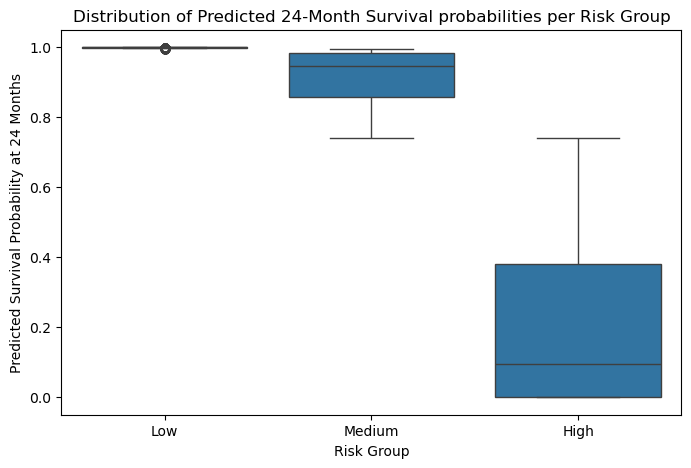

In [7]:
# Compute each customer's predicted risk (Partial hazard)
df_train["risk_score"] = cph.predict_partial_hazard(df_train)

# Group customers into risk segments
df_train["risk_group"] = pd.qcut(df_train["risk_score"], q=3,
                                 labels=["Low", "Medium", "High"])

# Visualize distribution of survival probabilities per segment.
predicted_surv = cph.predict_survival_function(df_train, times=[24])
df_train["survival_24"] = predicted_surv.T.iloc[:, 0].values
# Tanspose to match rows

# Plot distribution of survival probabilities per risk group
plt.figure(figsize=(8, 5))
sns.boxplot(x="risk_group", y="survival_24", data=df_train,
            order=["Low", "Medium", "High"])
plt.title("Distribution of Predicted 24-Month Survival probabilities per \
Risk Group")
plt.xlabel("Risk Group")
plt.ylabel("Predicted Survival Probability at 24 Months")
plt.show()

### Compare survival across groups

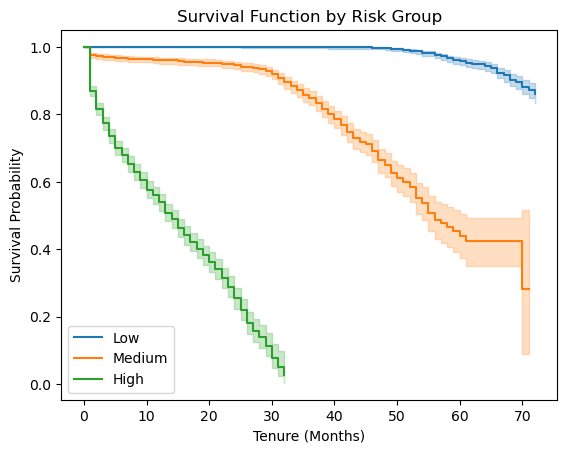

-------------------------------------------------------


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
        3491.52 <0.005       inf

In [8]:
# Plot Kaplan-Meier survival curves per risk segment.
# Instantiate the KM  estimator
kmf_group = KaplanMeierFitter()

for group in ["Low", "Medium", "High"]:
    mask = df_train["risk_group"] == group
    kmf_group.fit(df_train.loc[mask, "duration"], df_train.loc[mask, "event"],
                  label=group)
    kmf_group.plot_survival_function()

plt.title("Survival Function by Risk Group")
plt.xlabel("Tenure (Months)")
plt.ylabel("Survival Probability")
plt.show()

# Perform log-rank tests to statistically verify differences.
results = multivariate_logrank_test(
    event_durations=df_train["duration"],
    event_observed=df_train["event"],
    groups=df_train["risk_group"]
    )

print("-" * 55)
results.print_summary()

# Summarized business insights

### 1. Overall Survival Trends
Median survival time = ∞ → Most customers have not yet churned within the observation window.
This means your product/service has a substantial loyal customer base.

The aggregate survival function shows:
After 10 months, ~85.6% customers remain
After 30 months, ~77%.
After 50 months, ~70%.
After 68 months, ~62.5%.
→ Indicates gradual and steady attrition over time, not an abrupt churn event.

### 2. Model Performance
Concordance index (C-index) = 0.93 → The model’s predictive power is excellent.
This means the model is 93% accurate in ranking customers correctly by their churn risk.

### 3. Key Predictors of Customer Survival
| Feature                         | Coefficient | Hazard Ratio (exp(coef)) | Significance (p < 0.05?) | Interpretation                                                                                                       |
| ------------------------------- | ----------- | ------------------------ | ------------------------ | -------------------------------------------------------------------------------------------------------------------- |
| **Contract_Two year**           | -3.61       | 0.03                     | ✅                        | 2-year contracts *drastically reduce churn risk* (≈97% lower hazard).                                                |
| **Contract_One year**           | -1.30       | 0.27                     | ✅                        | 1-year contracts reduce churn risk by ≈73%.                                                                          |
| **PaperlessBilling_Yes**        | +0.22       | 1.24                     | ✅                        | Paperless billing users are 24% *more likely to churn* — possibly younger, more tech-savvy, and price-sensitive.     |
| **Partner_Yes**                 | -0.21       | 0.81                     | ✅                        | Having a partner reduces churn risk by ~19%. Stable households show stronger loyalty.                                |
| **InternetService_Fiber optic** | +0.84       | 2.33                     | ✅                        | Fiber users have *2.3× higher churn risk*. Possibly due to pricing or competitive alternatives.                      |
| **OnlineSecurity_Yes**          | -0.26       | 0.77                     | ✅                        | Customers with online security add-ons are 23% less likely to churn. Add-on services increase stickiness.            |
| **Avg_Monthly_Spend**           | +0.02       | 1.02                     | ✅                        | Each unit increase in spend slightly raises churn risk, perhaps reflecting higher cost dissatisfaction.              |
| **TotalCharges**                | -0.00       | ~1.00                    | ✅ (highly)               | Higher total spend (longer tenure) corresponds to *lower churn probability*. Loyal, long-term customers stay longer. |

### 4. Statistically Insignificant Predictors (p > 0.05)
Features like gender, seniorcitizen, dependents, phone service, streaming, and most payment methods showed no strong independent impact on churn risk once other variables were controlled for.
→ Marketing efforts shouldn’t prioritize these as segmentation levers.

### 5. Risk Group Analysis (Plots)
a. Kaplan-Meier Survival Curves
Clear separation between Low, Medium, and High risk groups.
Low risk: >85% survival even at 60 months.
Medium risk: drops sharply to ~50% survival by 50 months.
High risk: plummets below 20% survival within 30 months.
→ Your risk stratification is meaningful and the model discriminates well.

b. Boxplot of Predicted 24-Month Survival Probability
Low-risk group: survival ~1.0 (nearly all retained).
Medium-risk: median ~0.9, some churn expected.
High-risk: median ~0.1, strong signal of early departure.
→ Great for targeted retention marketing — focus efforts on high-risk customers.

### 6. Business Insights & Strategic Takeaways
Retention Strategy

Lock-in contracts work.
Customers with 1- or 2-year contracts are far less likely to churn.
→ Offer discounts or perks for contract renewals or upgrades.

Upsell protective services (Online Security, Tech Support).
These services are linked with higher customer loyalty.

Paperless billing users churn more.
→ Reassess pricing transparency, communication frequency, or incentives for paperless users.

Fiber optic users are volatile.
→ Investigate satisfaction issues (pricing, competition, service reliability).

High-spending customers (AvgMonthlySpend ↑) are riskier.
→ Introduce loyalty rewards, personalized offers, or tiered pricing to prevent value fatigue.

### Segmentation Implications
| Segment         | Typical Behavior                                         | Business Action                                            |
| --------------- | -------------------------------------------------------- | ---------------------------------------------------------- |
| **High-risk**   | Early churners, often Fiber users or paperless customers | Early retention campaigns, discounts, satisfaction surveys |
| **Medium-risk** | Cost-sensitive, moderate tenure                          | Convert to longer contracts, cross-sell add-ons            |
| **Low-risk**    | Contracted, partner households                           | Maintain engagement, encourage referrals                   |

### 8. Statistical Validation

Multivariate Log-Rank Test: χ² = 3489.25, p < 0.005
→ The difference in survival curves among the 3 risk groups is highly significant.

Partial log-likelihood ratio test: p < 0.005
→ Model is globally significant — predictors collectively explain churn well.

### Summary Table
| Category                        | Key Findings                                                      |
| ------------------------------- | ----------------------------------------------------------------- |
| **Best Predictor of Retention** | Contract length (especially 2-year contracts)                     |
| **Best Predictor of Churn**     | Fiber optic service, paperless billing, high average spend        |
| **Strongest Retention Driver**  | Online security add-ons, total historical spend, partner presence |
| **Model Quality**               | Concordance = 0.93 (Excellent)                                    |
| **Overall Trend**               | Gradual attrition, majority stable customers                      |


### Predict survival curve and lifetime of new customer/s

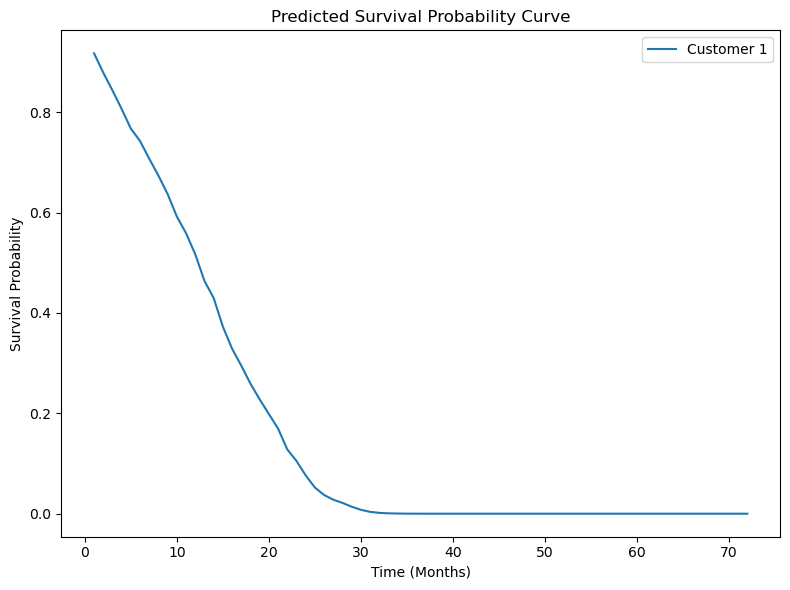

Expected lifetime (median time) per customer: 
Customer 1: 13.00 months


(             0
 1.0   0.917247
 2.0   0.878774
 3.0   0.843412
 4.0   0.806306
 5.0   0.767154
 ...        ...
 68.0  0.000000
 69.0  0.000000
 70.0  0.000000
 71.0  0.000000
 72.0  0.000000
 
 [72 rows x 1 columns],
 [np.float64(13.0)])

In [9]:
## Predict lifetime of new cutomers
# Create a function for lifetime prediction of new customers


def pred_lifetime(cox_model, cust: pd.Series):
    """Predict the lifetime of new customers."""
    # Predict survival function for new customer/s
    surv_function = cox_model.predict_survival_function(cust)

    # Plot survival probability curve    
    plt.figure(figsize=(8, 6))
    for i, col in enumerate(surv_function.columns):
        plt.plot(surv_function.index, surv_function[col],
                 label=f"Customer {i+1}")
    plt.title("Predicted Survival Probability Curve")
    plt.xlabel("Time (Months)")
    plt.ylabel("Survival Probability")
    plt.tight_layout()
    plt.legend()
    plt.show()

    # Compute expected lifetime (median time)
    expected_lifetime = []
    for i, col in enumerate(surv_function.columns):
        prob = surv_function[col]
        median_time = prob[prob <= 0.5].index.min()  
        # Time where survival <= 0.5
        expected_lifetime.append(median_time)

    print("Expected lifetime (median time) per customer: ")
    for i, val in enumerate(expected_lifetime):
        print(f"Customer {i+1}: {val:.2f} months")

    return surv_function, expected_lifetime


def align_with_test(df_test, new_customer):
    """
    Align new customer's features with df_test structure.
    Missing columns → 0, Extra columns → dropped.
    Drop duration and event columns
    """
    df_ref = df_test.drop(["duration", "event"], axis=1, errors="ignore")
    new_customer_encoded = pd.get_dummies(new_customer, drop_first=True)
    new_customer_encoded = new_customer_encoded.reindex(columns=df_ref.columns,
                                                        fill_value=0)
    return new_customer_encoded



new_customer = pd.DataFrame({
    'gender_Female': [1],
    'seniorcitizen': [0],
    'partner_Yes': [1],
    'dependents_Yes': [0],
    'phoneservice_Yes': [1],
    'multiplelines_Yes': [0],
    'internetservice_Fiber optic': [1],
    'onlinesecurity_Yes': [0],
    'onlinebackup_Yes': [1],
    'techsupport_Yes': [0],
    'contract_Two year': [0],
    'paperlessbilling_Yes': [1],
    'paymentmethod_Electronic check': [1],
    'monthlycharges': [75.0],
    'totalcharges': [900.0]
})

new_cust_encoded = align_with_test(df_test, new_customer)
pred_lifetime(cph, new_cust_encoded)